<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 1 (effective batch size ≈ 16, tuned value = 17)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 1.43e-04 | train loss 1.3247 acc 0.576 | val loss 0.6705 acc 0.753 *


[InceptionNet v3] Epoch   2/100 | LR: 1.43e-04 | train loss 0.9392 acc 0.732 | val loss 0.5216 acc 0.807 *


[InceptionNet v3] Epoch   3/100 | LR: 1.43e-04 | train loss 0.7703 acc 0.777 | val loss 0.5591 acc 0.805


[InceptionNet v3] Epoch   4/100 | LR: 1.43e-04 | train loss 0.6177 acc 0.822 | val loss 0.5953 acc 0.803


[InceptionNet v3] Epoch   5/100 | LR: 1.43e-04 | train loss 0.6096 acc 0.820 | val loss 0.5049 acc 0.832 *


...

[InceptionNet v3] Epoch  14/100 | LR: 1.43e-04 | train loss 0.3304 acc 0.907 | val loss 0.5032 acc 0.862


[InceptionNet v3] Epoch  15/100 | LR: 1.43e-04 | train loss 0.2635 acc 0.928 | val loss 0.5018 acc 0.871


[InceptionNet v3] Epoch  16/100 | LR: 1.43e-04 | train loss 0.2884 acc 0.924 | val loss 0.6271 acc 0.878


[InceptionNet v3] Epoch  17/100 | LR: 1.43e-04 | train loss 0.2798 acc 0.935 | val loss 0.5567 acc 0.866


[InceptionNet v3] Epoch  18/100 | LR: 1.43e-04 | train loss 0.2168 acc 0.953 | val loss 0.5614 acc 0.859

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 18.

[InceptionNet v3] Restored best checkpoint (val loss = 0.3731)


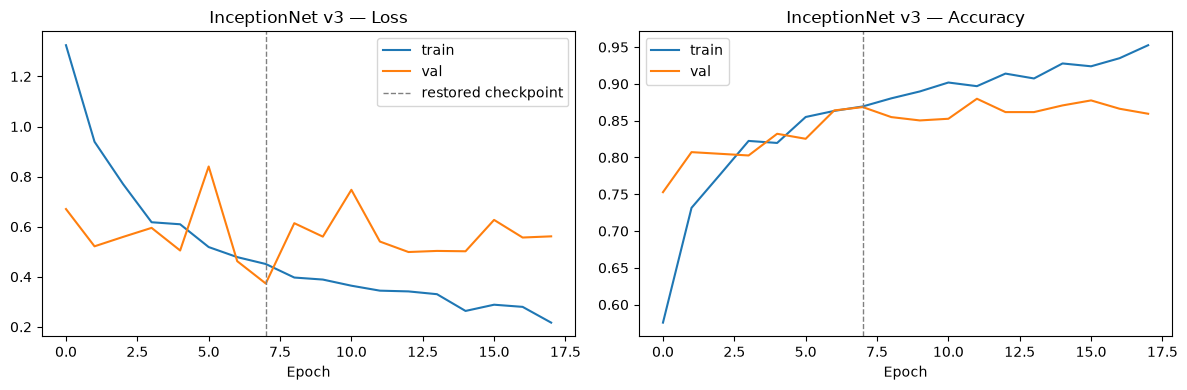

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.750


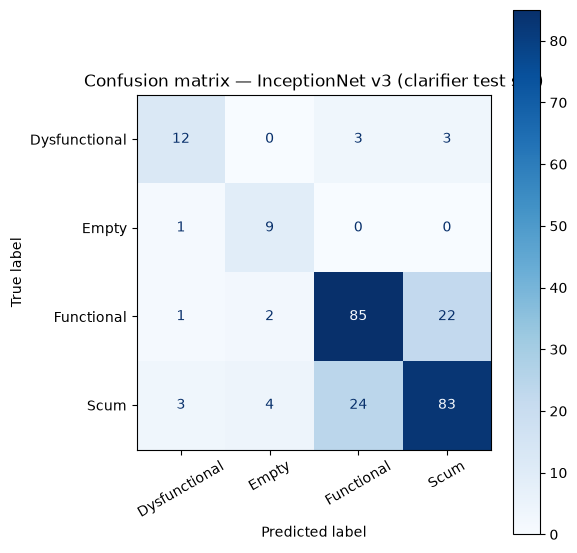

               precision    recall  f1-score   support

Dysfunctional      0.706     0.667     0.686        18
        Empty      0.600     0.900     0.720        10
   Functional      0.759     0.773     0.766       110
         Scum      0.769     0.728     0.748       114

     accuracy                          0.750       252
    macro avg      0.708     0.767     0.730       252
 weighted avg      0.753     0.750     0.750       252



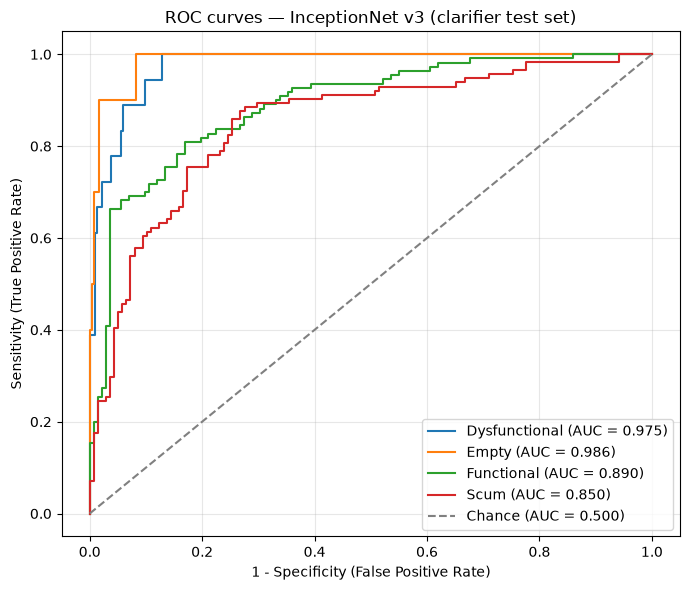

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.975
  Empty          : 0.986
  Functional     : 0.890
  Scum           : 0.850

Mean AUC (over 4/4 classes with test examples): 0.925


(np.float64(0.75),
 {'Dysfunctional': 0.9750712250712251,
  'Empty': 0.9863636363636364,
  'Functional': 0.890460947503201,
  'Scum': 0.8495423340961098})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_clarifier_inception_v3_Fisantekraal.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
